In [3]:
%pip install yfinance pandas numpy  scikit-learn matplotlib 


  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("libraries installed successfully!")

libraries installed successfully!


In [5]:
data = yf.download("GC=F", interval = "1d", period="2y")

[*********************100%***********************]  1 of 1 completed


In [6]:
data.to_csv('data')

In [7]:

data.shape
data.isna().sum()

Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64

In [8]:
data.head(2)


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2024-07-22,2392.000000,2402.100098,2392.000000,2402.100098,18
2024-07-23,2404.600098,2404.600098,2388.699951,2395.800049,41


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-22 to 2026-07-21
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   503 non-null    float64
 1   (High, GC=F)    503 non-null    float64
 2   (Low, GC=F)     503 non-null    float64
 3   (Open, GC=F)    503 non-null    float64
 4   (Volume, GC=F)  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


In [10]:
data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-22 to 2026-07-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   503 non-null    float64
 1   High    503 non-null    float64
 2   Low     503 non-null    float64
 3   Open    503 non-null    float64
 4   Volume  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


To handle look ahead Leakage 

In [12]:
data["tomorrow_close"] = data["Close"].shift(-1)
data['direction'] = np.where(data["tomorrow_close"] > data["Close"], 1, 0)
data.dropna(subset=["tomorrow_close"], inplace = True)
data["direction"].value_counts()






direction
1    288
0    214
Name: count, dtype: int64

<Axes: title={'center': 'Gold Price'}, xlabel='Date'>

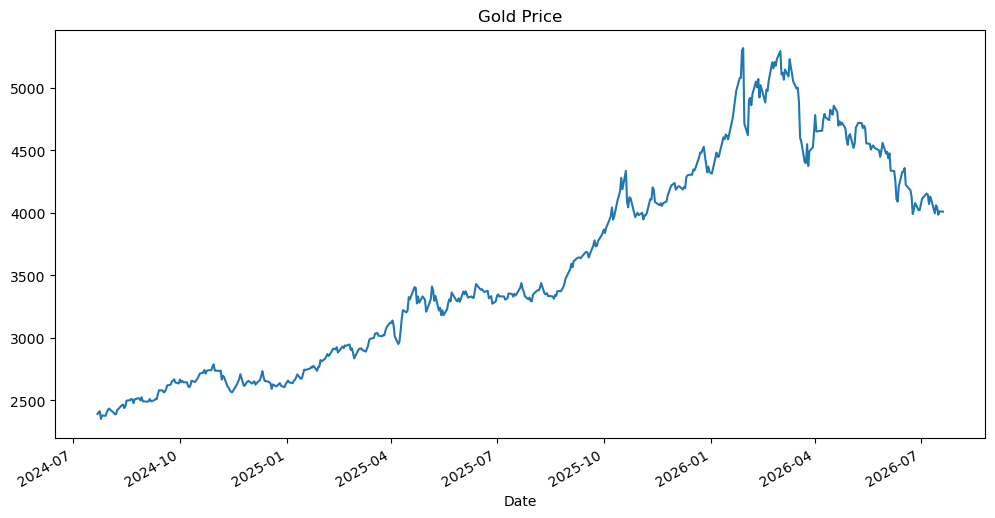

In [13]:
#plotting a graph to check the movement and trend of gold ove the last two years 

data['Close'].plot(title = "Gold Price", figsize = (12,6))

In [14]:
#the quantitative mathematics

# 1. Previous Candle Return
data['pcr'] = data['Close'].pct_change(1)

# 2. High-Low Range %
data['hlr'] = (data['High'] - data['Low']) / data['Close']

# 3. SMA Difference (5-period minus 20-period)
data['sma_diff'] = data['Close'].rolling(window=5).mean() - data['Close'].rolling(window=20).mean()

### 4. RSI (14-period)
# calculating day-to-day price differences
delta = data['Close'].diff()

# Isolating daily gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

#  the 14-period exponential moving averages of gains and losses
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()

#  Relative Strength (RS) and scale to the 0-100 RSI boundaries
rs = avg_gain / avg_loss
data['rsi'] = 100 - (100 / (1 + rs))





####5. Average True Range
#  the three absolute metrics that make up the "True Range"
high_low = data['High'] - data['Low']
high_close_prev = (data['High'] - data['Close'].shift(1)).abs()
low_close_prev = (data['Low'] - data['Close'].shift(1)).abs()

# Stacing 'em horizontally and findinf the maximum true struggle per day
true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)

# Averaging d True Range over a 14-day rolling window
data['atr'] = true_range.rolling(window=14).mean()




In [15]:
data.shape

(502, 12)

In [16]:
#my features
#where 
#pcr = previous candle returns
#atr = average true range
#sma_diff = sma difference(5-day_period - 20-day_period)
#hlr = high low range
#rsi = relative strenght index

X = data[["pcr", "atr", "sma_diff", "hlr", "rsi"]]


#my target
y = data["direction"]

In [17]:

data.dropna(inplace = True)

data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'tomorrow_close', 'direction',
       'pcr', 'hlr', 'sma_diff', 'rsi', 'atr'],
      dtype='object')

In [18]:
data.drop(columns=['tomorrow_close'], inplace=True, errors='ignore', axis=0)

In [19]:
data.head(50)

,Close,High,Low,Open,Volume,direction,pcr,hlr,sma_diff,rsi,atr
Date,,,,,,,,,,,
2024-08-16,2498.600098,2508.000000,2451.399902,2453.500000,197,1,0.018548,0.022653,45.684985,74.291856,38.557199
2024-08-19,2501.800049,2508.500000,2487.199951,2508.500000,88,1,0.001281,0.008514,48.075012,74.627500,37.542916
2024-08-20,2511.300049,2527.300049,2500.699951,2503.500000,187,0,0.003797,0.010592,51.660034,75.644163,36.242920
2024-08-21,2508.399902,2515.399902,2503.899902,2511.000000,96,0,-0.001155,0.004585,60.705042,74.660636,35.021484
2024-08-22,2478.899902,2504.100098,2471.100098,2504.100098,210,1,-0.011760,0.013312,59.515002,65.352555,33.328613
2024-08-23,2508.399902,2508.399902,2486.500000,2486.500000,94,1,0.011900,0.008731,55.054968,69.453755,29.550031
2024-08-26,2517.699951,2523.100098,2509.100098,2509.899902,290,0,0.003708,0.005561,51.214954,70.633896,27.614328
2024-08-27,2516.000000,2523.100098,2506.899902,2515.199951,100,0,-0.000675,0.006439,46.604944,70.100764,27.592913
2024-08-28,2501.000000,2501.000000,2501.000000,2501.000000,2353,1,-0.005962,0.000000,41.399963,65.409378,25.914342


In [20]:
#spliting the index to know where my 80% lies at since i cannot
#perform a train-test-split on time-series data

split_idx = int(len(data) * 0.80)

In [21]:
# Slicing the features (X)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

# Slicing the target (y)
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


In [22]:
# Verify dimensions
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(386, 5) (116, 5)
(386,) (116,)


In [23]:
data.head

<bound method NDFrame.head of                   Close         High          Low         Open  Volume  \
Date                                                                     
2024-08-16  2498.600098  2508.000000  2451.399902  2453.500000     197   
2024-08-19  2501.800049  2508.500000  2487.199951  2508.500000      88   
2024-08-20  2511.300049  2527.300049  2500.699951  2503.500000     187   
2024-08-21  2508.399902  2515.399902  2503.899902  2511.000000      96   
2024-08-22  2478.899902  2504.100098  2471.100098  2504.100098     210   
...                 ...          ...          ...          ...     ...   
2026-07-14  4061.100098  4091.199951  3986.500000  3995.699951    1281   
2026-07-15  4044.000000  4070.100098  4019.399902  4049.100098     374   
2026-07-16  3985.600098  4030.500000  3972.600098  4030.500000     812   
2026-07-17  4012.699951  4017.199951  3964.199951  3975.500000     141   
2026-07-20  4010.300049  4018.899902  4002.699951  4003.399902     141   

       

In [33]:
%pip install sklearn


from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [31]:
print(y_train.shape)


(386,)


In [26]:

model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [27]:
#prediction and confidence proabilities

#1.
y_pred = model.predict(X_test)

#2.
probabilities = model.predict_proba(X_test)


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# my core four metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

##
print(f"Directional Accuracy: {accuracy:.4f}")
print(f"Precision Score (Up Days): {precision:.4f}")
print(f"Recall Score (Up Days): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Directional Accuracy: 0.4741
Precision Score (Up Days): 0.4648
Recall Score (Up Days): 0.5893
F1 Score: 0.5197


In [29]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix Layout:")
print(cm)



Confusion Matrix Layout:
[[22 38]
 [23 33]]


In [ ]:
import joblib
import os

# creating the folder structure
os.makedirs('model', exist_ok=True)

# serialize the trained model architecture into a permanent file
joblib.dump(model, 'model/model.pkl')


['model/model.pkl']